# BeautifulSoup Documentation Analytics
**Source:** https://www.crummy.com/software/BeautifulSoup/bs4/doc/

Run `python -m pipeline.pipeline` before executing this notebook.

In [1]:
import sys, re
from pathlib import Path
from collections import Counter
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

from shared.utils import load_sections, load_links, load_code_examples, load_summary_stats
from shared.constants import LINK_TYPES, STOPWORDS, CHARTS_DIR

sections = load_sections()
links    = load_links()
code     = load_code_examples()
summary  = load_summary_stats()

bool_cols = ['contains_find_all','contains_find','contains_select',
             'contains_get_text','contains_requests']
for col in bool_cols:
    code[col] = code[col].astype(bool)

print(f'Sections : {len(sections)} rows')
print(f'Links    : {len(links)} rows')
print(f'Code     : {len(code)} rows')

Sections : 113 rows
Links    : 376 rows
Code     : 220 rows


## Dataset Overview

In [2]:
print('=== Sections sample ===')
display(sections[['section_id','section_level','section_title','word_count']].head())
print('\n=== Word count statistics ===')
display(sections['word_count'].describe().round(1))

=== Sections sample ===


,section_id,section_level,section_title,word_count
0,0,1,Beautiful Soup Documentation,310
1,1,2,Getting help,97
2,2,3,API documentation,43
3,3,1,Quick Start,422
4,4,1,Installing Beautiful Soup,431



=== Word count statistics ===


count     113.0
mean      363.3
std       567.9
min         0.0
25%       103.0
50%       177.0
75%       362.0
max      4711.0
Name: word_count, dtype: float64

## Q1 - How many sections are in the documentation?

In [3]:
total = len(sections)
by_level = sections['section_level'].value_counts().sort_index()
print(f'Total sections: {total}')
print(f'  H1 sections: {by_level.get(1,0)}')
print(f'  H2 sections: {by_level.get(2,0)}')
print(f'  H3 sections: {by_level.get(3,0)}')

Total sections: 113
  H1 sections: 19
  H2 sections: 52
  H3 sections: 42


## Q2 - Which section has the highest word count?

In [4]:
top_section = sections.loc[sections['word_count'].idxmax()]
avg = sections['word_count'].mean()
print(f'Section : {top_section["section_title"]}')
print(f'Words   : {top_section["word_count"]:,}')
print(f'Average : {avg:.1f} words per section')
print(f'Ratio   : {top_section["word_count"]/avg:.1f}x the average')

top10 = sections.nlargest(10,'word_count')[['section_title','word_count']]
fig = px.bar(top10, x='word_count', y='section_title', orientation='h',
             color='word_count', color_continuous_scale='Blues',
             title='Top 10 Sections by Word Count',
             labels={'word_count':'Word Count','section_title':'Section'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False)
fig.show()

Section : Searching the tree
Words   : 4,711
Average : 363.3 words per section
Ratio   : 13.0x the average


## Q3 - Which section contains the most code examples?

In [5]:
code_counts = code.groupby('section_title').size().sort_values(ascending=False)
print(f'Section : {code_counts.index[0]}')
print(f'Count   : {code_counts.iloc[0]} code examples')
print(f'\nTop 10:')
display(code_counts.head(10).reset_index().rename(columns={0:'count','section_title':'Section'}))

fig = px.bar(code_counts.head(10).reset_index(),
             x='section_title', y=0,
             title='Top 10 Sections by Code Example Count',
             labels={'section_title':'Section', 0:'Code Examples'},
             color=0, color_continuous_scale='Teal')
fig.update_xaxes(tickangle=40)
fig.show()

Section : Multi-valued attributes
Count   : 13 code examples

Top 10:


,Section,count
0,Multi-valued attributes,13
1,CSS selectors through the.cssproperty,12
2,The keyword arguments,9
3,Output formatters,8
4,Searching by CSS class,7
5,.next_siblingand.previous_sibling,6
6,Kinds of objects,6
7,Encodings,6
8,Advanced Soup Sieve features,5
9,Output encoding,5


## Q4 - Which section contains the most links?

In [6]:
link_counts = links.groupby('section_title').size().sort_values(ascending=False)
print(f'Section : {link_counts.index[0]}')
print(f'Count   : {link_counts.iloc[0]} links')
print(f'\nNote: Table of Contents is expected to have the most links')
print(f'Excluding TOC - next highest: {link_counts.index[1]} ({link_counts.iloc[1]} links)')
display(link_counts.head(10).reset_index().rename(columns={0:'count'}))

Section : Table of Contents
Count   : 128 links

Note: Table of Contents is expected to have the most links
Excluding TOC - next highest: Parsing only part of a document (17 links)


,section_title,count
0,Table of Contents,128
1,Parsing only part of a document,17
2,Multi-valued attributes,16
3,For XML documents,11
4,find_all_previous()andfind_previous(),11
5,Custom element filtering,11
6,find_all_next()andfind_next(),11
7,find_parents()andfind_parent(),11
8,Miscellaneous,10
9,find_next_siblings()andfind_next_sibling(),10


## Q5 — Top 10 most frequent technical keywords

In [7]:
all_text = ' '.join(sections['section_text'].fillna('')).lower()
words    = re.findall(r'\b[a-z][a-z0-9_]{2,}\b', all_text)
counts   = Counter(w for w in words if w not in STOPWORDS)
top10    = counts.most_common(10)

print('Top 10 keywords by raw frequency:')
for rank, (word, count) in enumerate(top10, 1):
    print(f'  {rank:2}. {word:<20} {count:,}')

kw_df = pd.DataFrame(top10, columns=['keyword','count'])
fig = px.bar(kw_df, x='count', y='keyword', orientation='h',
             color='count', color_continuous_scale='Greens',
             title='Top 10 Keywords — Raw Frequency',
             labels={'count':'Occurrences','keyword':'Keyword'})
fig.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False)
fig.show()

Top 10 keywords by raw frequency:
   1. soup                 926
   2. tag                  746
   3. class                511
   4. html                 420
   5. example              419
   6. string               387
   7. com                  383
   8. href                 378
   9. http                 363
  10. beautiful            351


## Q6 — How many internal and external links exist?

In [8]:
type_counts = links['link_type'].value_counts()
total_links = len(links)
print('Link type breakdown:')
for lt, cnt in type_counts.items():
    print(f'  {lt:<25} {cnt:>4}  ({cnt/total_links*100:.1f}%)')

fig = px.pie(values=type_counts.values, names=type_counts.index,
             title='Link Type Distribution',
             color_discrete_sequence=px.colors.qualitative.Set2, hole=0.3)
fig.update_traces(textinfo='percent+label')
fig.show()

Link type breakdown:
  internal_anchor            342  (91.0%)
  external_link               21  (5.6%)
  documentation_link          11  (2.9%)
  empty_or_invalid             2  (0.5%)


## Q7 — How many code examples use find_all()?

In [9]:
n = int(code['contains_find_all'].sum())
pct = n / len(code) * 100
print(f'find_all() appears in {n} / {len(code)} examples ({pct:.1f}%)')
print(f'This makes it the most-demonstrated method in the documentation.')

find_all() appears in 41 / 220 examples (18.6%)
This makes it the most-demonstrated method in the documentation.


## Q8 — How many code examples use get_text()?

In [10]:
n = int(code['contains_get_text'].sum())
pct = n / len(code) * 100
print(f'get_text() appears in {n} / {len(code)} examples ({pct:.1f}%)')

# Full method comparison
method_cols   = ['contains_find_all','contains_find','contains_select',
                 'contains_get_text','contains_requests']
method_labels = ['find_all()','find()','select()','get_text()','requests']
method_counts = [int(code[c].sum()) for c in method_cols]
method_pcts   = [c / len(code) * 100 for c in method_counts]

print('\nAll method usage:')
for label, cnt, pct in zip(method_labels, method_counts, method_pcts):
    print(f'  {label:<15} {cnt:>3} examples  ({pct:.1f}%)')

fig = px.bar(x=method_labels, y=method_counts,
             title='BS4 Method Usage in Code Examples',
             labels={'x':'Method','y':'# Examples'},
             color=method_counts, color_continuous_scale='Purples')
fig.show()

get_text() appears in 4 / 220 examples (1.8%)

All method usage:
  find_all()       41 examples  (18.6%)
  find()           14 examples  (6.4%)
  select()         14 examples  (6.4%)
  get_text()        4 examples  (1.8%)
  requests          0 examples  (0.0%)


## Q9 (team-proposed) — Average word count per section

In [11]:
avg    = sections['word_count'].mean()
median = sections['word_count'].median()
std    = sections['word_count'].std()
print(f'Mean   : {avg:.1f} words')
print(f'Median : {median:.1f} words')
print(f'Std    : {std:.1f}')
print(f'Min    : {sections["word_count"].min()}')
print(f'Max    : {sections["word_count"].max():,}')

fig = px.histogram(sections, x='word_count', nbins=30,
                   title='Distribution of Section Word Counts',
                   labels={'word_count':'Word Count'})
fig.add_vline(x=avg, line_dash='dash', line_color='red',
              annotation_text=f'Mean {avg:.0f}')
fig.show()

Mean   : 363.3 words
Median : 177.0 words
Std    : 567.9
Min    : 0
Max    : 4,711


## Q10 (team-proposed) — Sections with zero code examples

In [12]:
no_code = sections[sections['code_block_count'] == 0]
print(f'{len(no_code)} of {len(sections)} sections have no code blocks ({len(no_code)/len(sections)*100:.1f}%)')
print('\nSections with no code:')
display(no_code[['section_title','section_level','word_count']]
        .sort_values('word_count',ascending=False))

22 of 113 sections have no code blocks (19.5%)

Sections with no code:


,section_title,section_level,word_count
4,Installing Beautiful Soup,1,431
0,Beautiful Soup Documentation,1,310
100,Miscellaneous,2,304
111,Table of Contents,3,295
5,Installing a parser,2,215
110,Miscellaneous,3,191
102,Translating this documentation,1,144
96,Errors when parsing a document,2,144
101,Improving Performance,2,139
99,Other parser problems,2,135


## Advanced A1 — TF-IDF vs Raw Frequency Comparison

TF-IDF top 10:
   1. tag                  13.2991
   2. soup                 13.2629
   3. class                7.7891
   4. html                 7.4666
   5. com                  7.4088
   6. example              7.3839
   7. beautiful            7.2256
   8. string               7.1993
   9. title                6.6429
  10. document             6.3862

Words in both rankings: {'html', 'example', 'beautiful', 'tag', 'class', 'com', 'soup', 'string'}
Words only in raw freq: {'href', 'http'}
Words only in TF-IDF : {'title', 'document'}


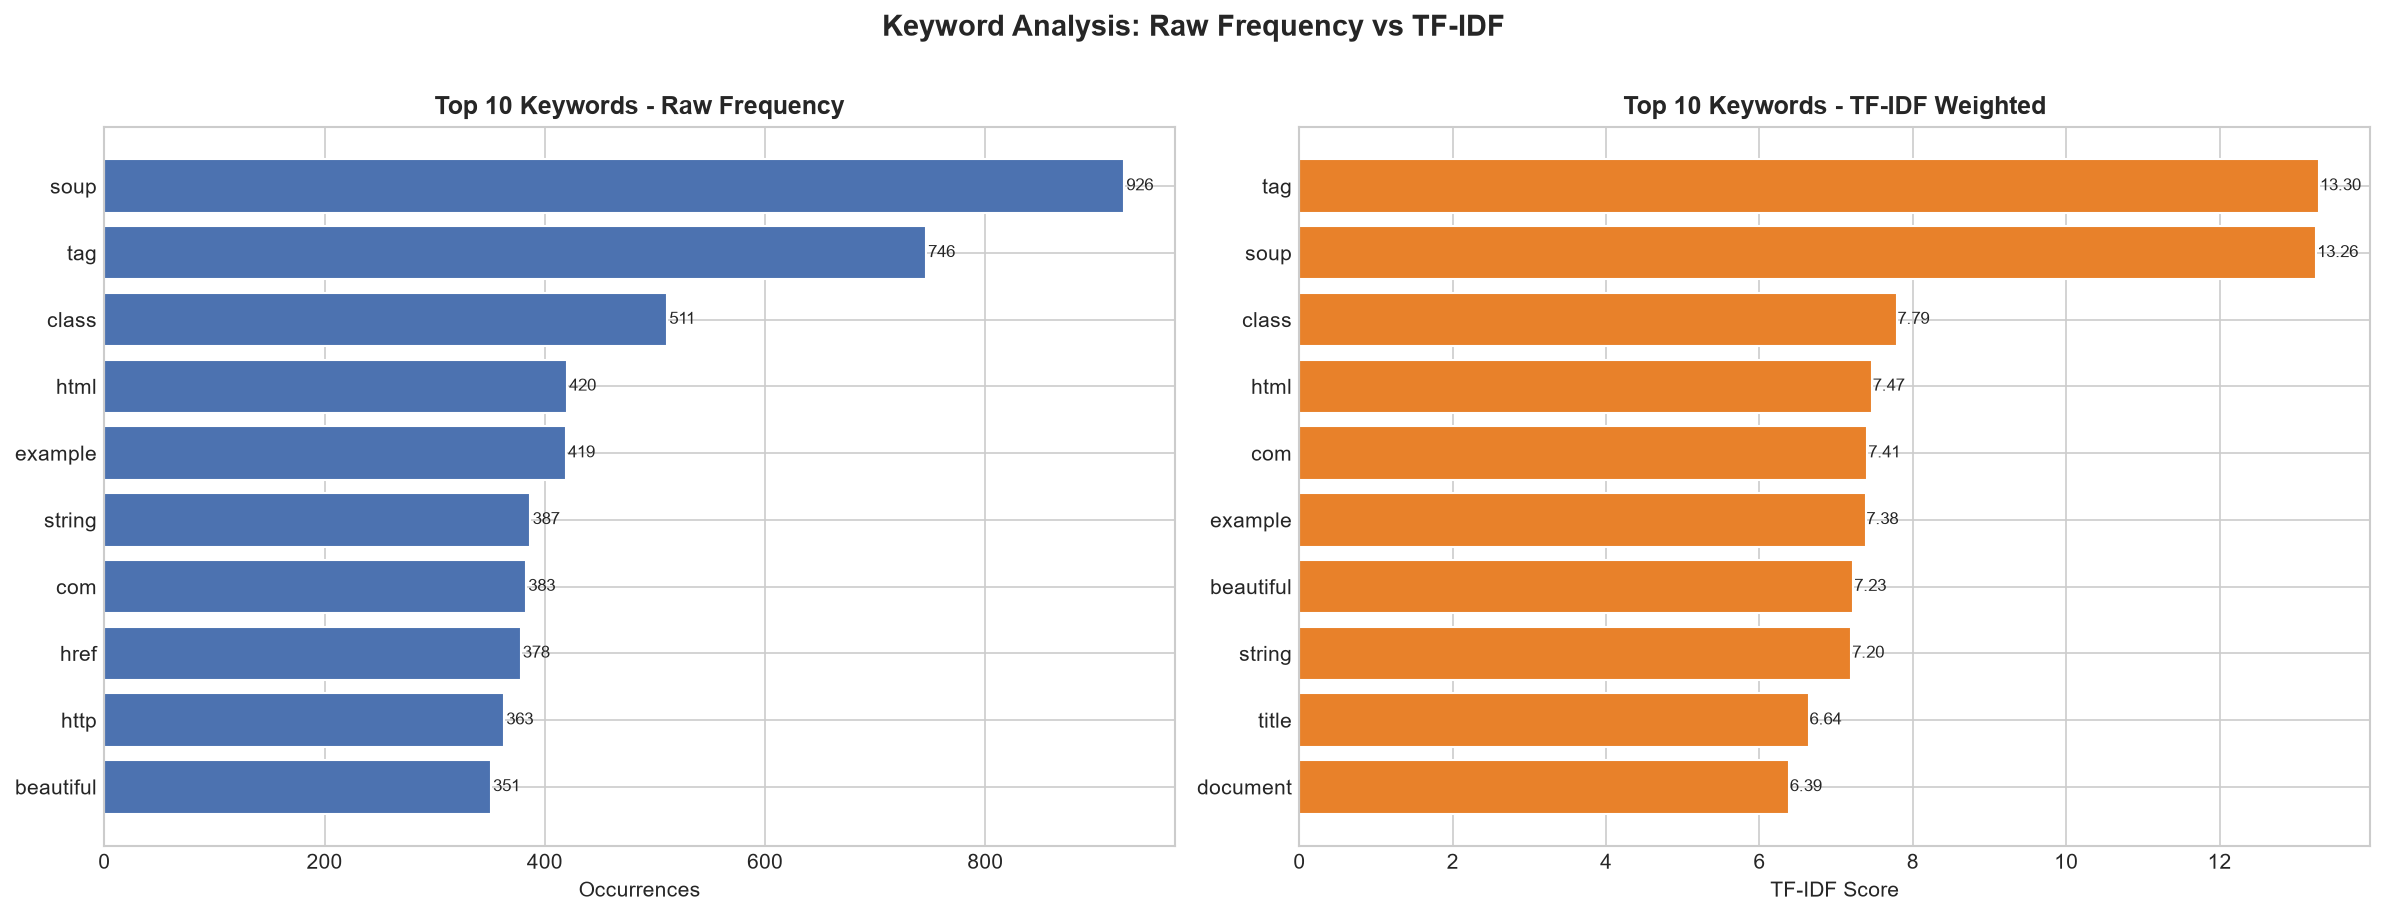

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
vec    = TfidfVectorizer(stop_words='english', max_features=500)
X      = vec.fit_transform(sections['section_text'].fillna(''))
scores = X.toarray().sum(axis=0)
terms  = vec.get_feature_names_out()
tfidf_top10 = sorted(zip(terms, scores), key=lambda x: -x[1])[:10]

print('TF-IDF top 10:')
for rank, (word, score) in enumerate(tfidf_top10, 1):
    print(f'  {rank:2}. {word:<20} {score:.4f}')

# Side-by-side comparison
raw_words  = [w for w, _ in top10]
tfidf_words = [w for w, _ in tfidf_top10]
overlap = set(raw_words) & set(tfidf_words)
print(f'\nWords in both rankings: {overlap}')
print(f'Words only in raw freq: {set(raw_words) - set(tfidf_words)}')
print(f'Words only in TF-IDF : {set(tfidf_words) - set(raw_words)}')

# Display chart from file
from IPython.display import Image
Image(str(CHARTS_DIR / 'tfidf_keywords.png'))

## Advanced A2 — Readability Analysis

Mean  Flesch score: 55.99
Scale: 90-100=Very Easy, 70-90=Easy, 60-70=Standard, 30-60=Difficult, 0-30=Very Difficult

5 easiest sections:


,section_title,readability
33,True,93.616773
107,Generators,89.440000
32,A regular expression,81.692962
17,.string,81.136413
31,A string,78.801913



5 hardest sections:


,section_title,readability
111,Table of Contents,-4.639025
112,Quick search,0.000000
47,find_previous_siblings()andfind_previous_sibli...,21.057944
46,find_next_siblings()andfind_next_sibling(),26.581526
5,Installing a parser,29.557745


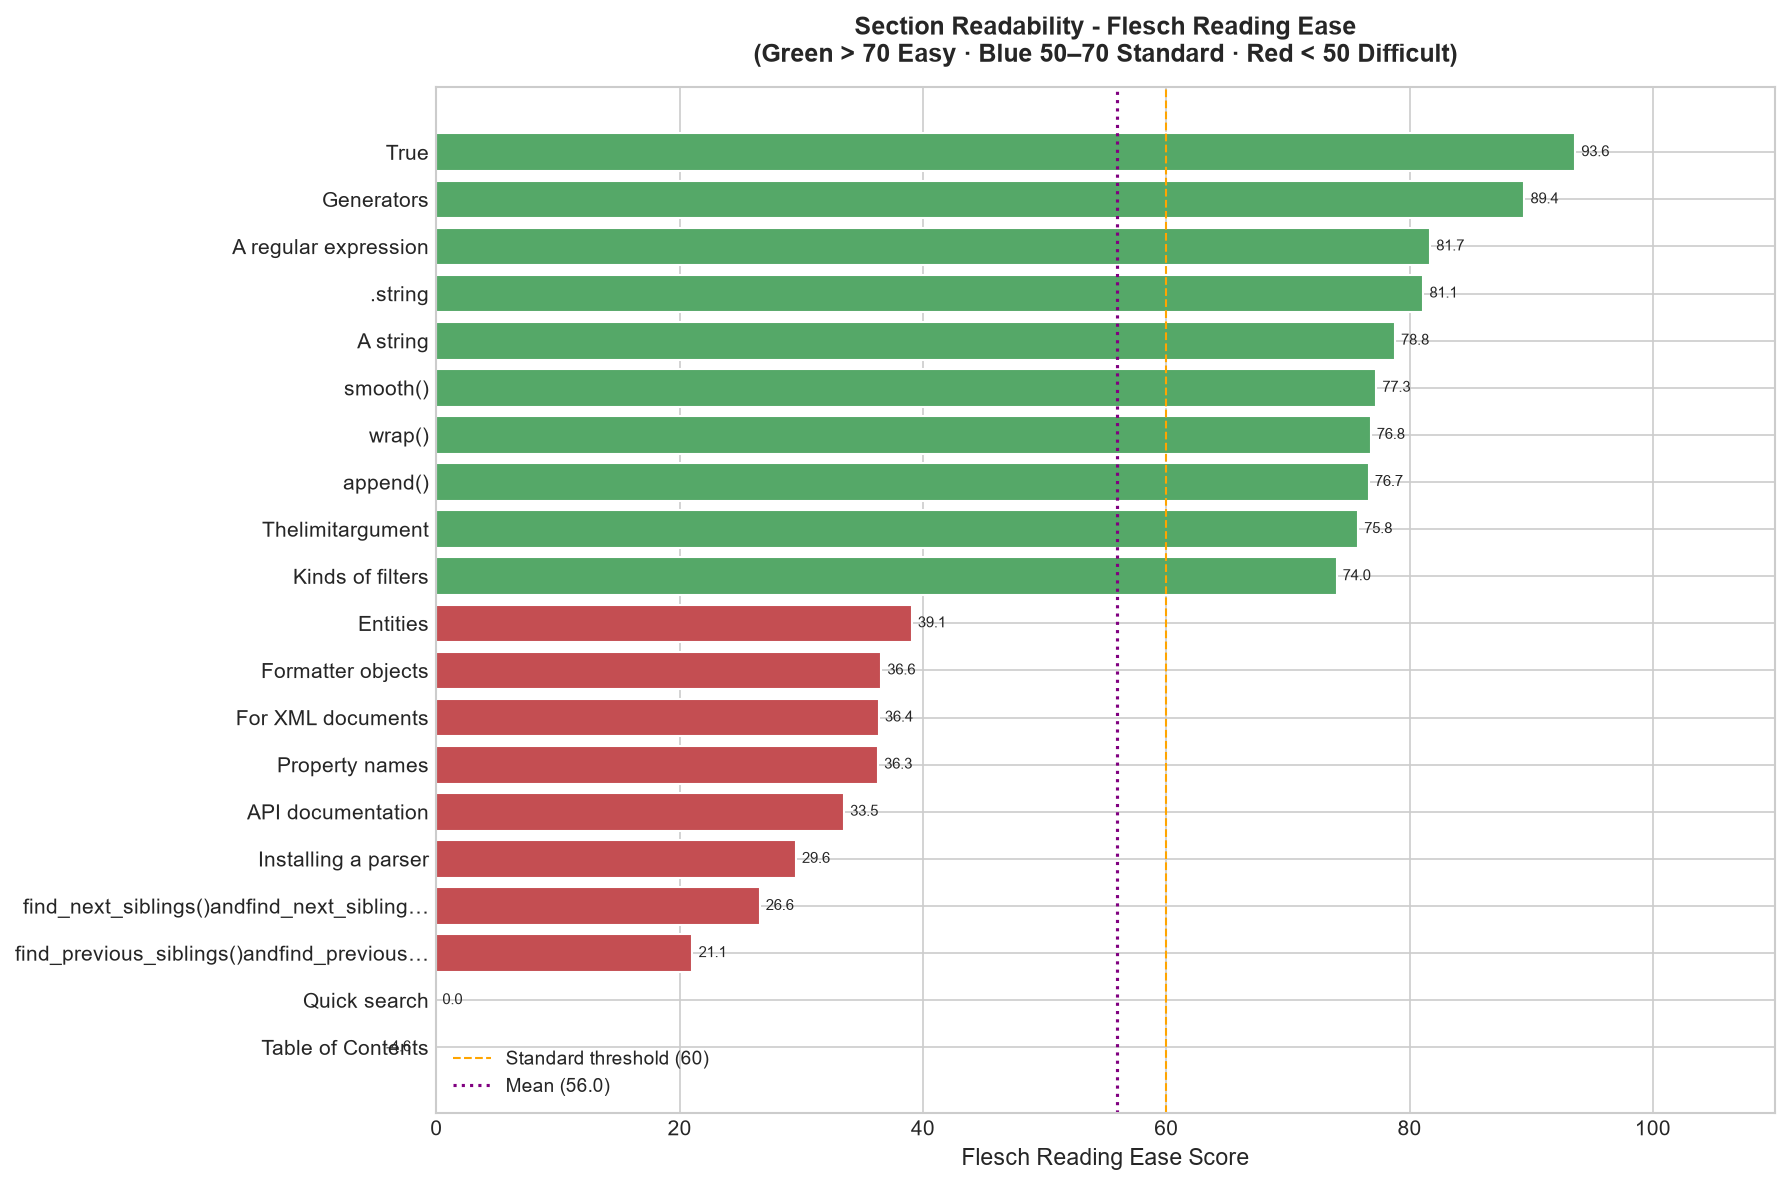

In [14]:
import textstat

scores_series = sections['section_text'].fillna('').apply(textstat.flesch_reading_ease)
sections_with_scores = sections.copy()
sections_with_scores['readability'] = scores_series.values

print(f'Mean  Flesch score: {scores_series.mean():.2f}')
print(f'Scale: 90-100=Very Easy, 70-90=Easy, 60-70=Standard, 30-60=Difficult, 0-30=Very Difficult')
print()
print('5 easiest sections:')
easiest = sections_with_scores.nlargest(5,'readability')[['section_title','readability']]
display(easiest)
print()
print('5 hardest sections:')
hardest = sections_with_scores.nsmallest(5,'readability')[['section_title','readability']]
display(hardest)

# Histogram of all scores
fig = px.histogram(sections_with_scores, x='readability', nbins=20,
                   title='Distribution of Flesch Reading Ease Scores',
                   labels={'readability':'Flesch Score'})
fig.add_vline(x=scores_series.mean(), line_dash='dash', line_color='red',
              annotation_text=f'Mean {scores_series.mean():.1f}')
fig.show()

Image(str(CHARTS_DIR / 'readability_by_section.png'))

## Advanced A3 — Section Cosine Similarity

Top 10 most similar section pairs:
  0.977  Low-level search interface          ↔  Custom element filtering
  0.938  Beautiful Soup 3                    ↔  Porting code to BS4
  0.926  Going sideways                      ↔  .next_siblingand.previous_sibling
  0.915  Output                              ↔  Output formatters
  0.910  Specifying the parser to use        ↔  Differences between parsers
  0.900  Searching the tree                  ↔  find_all()
  0.889  Going back and forth                ↔  .next_elementand.previous_element
  0.857  find_all()                          ↔  The keyword arguments
  0.849  Searching the tree                  ↔  CSS selectors through the.cssproper
  0.843  Installing Beautiful Soup           ↔  Installing a parser


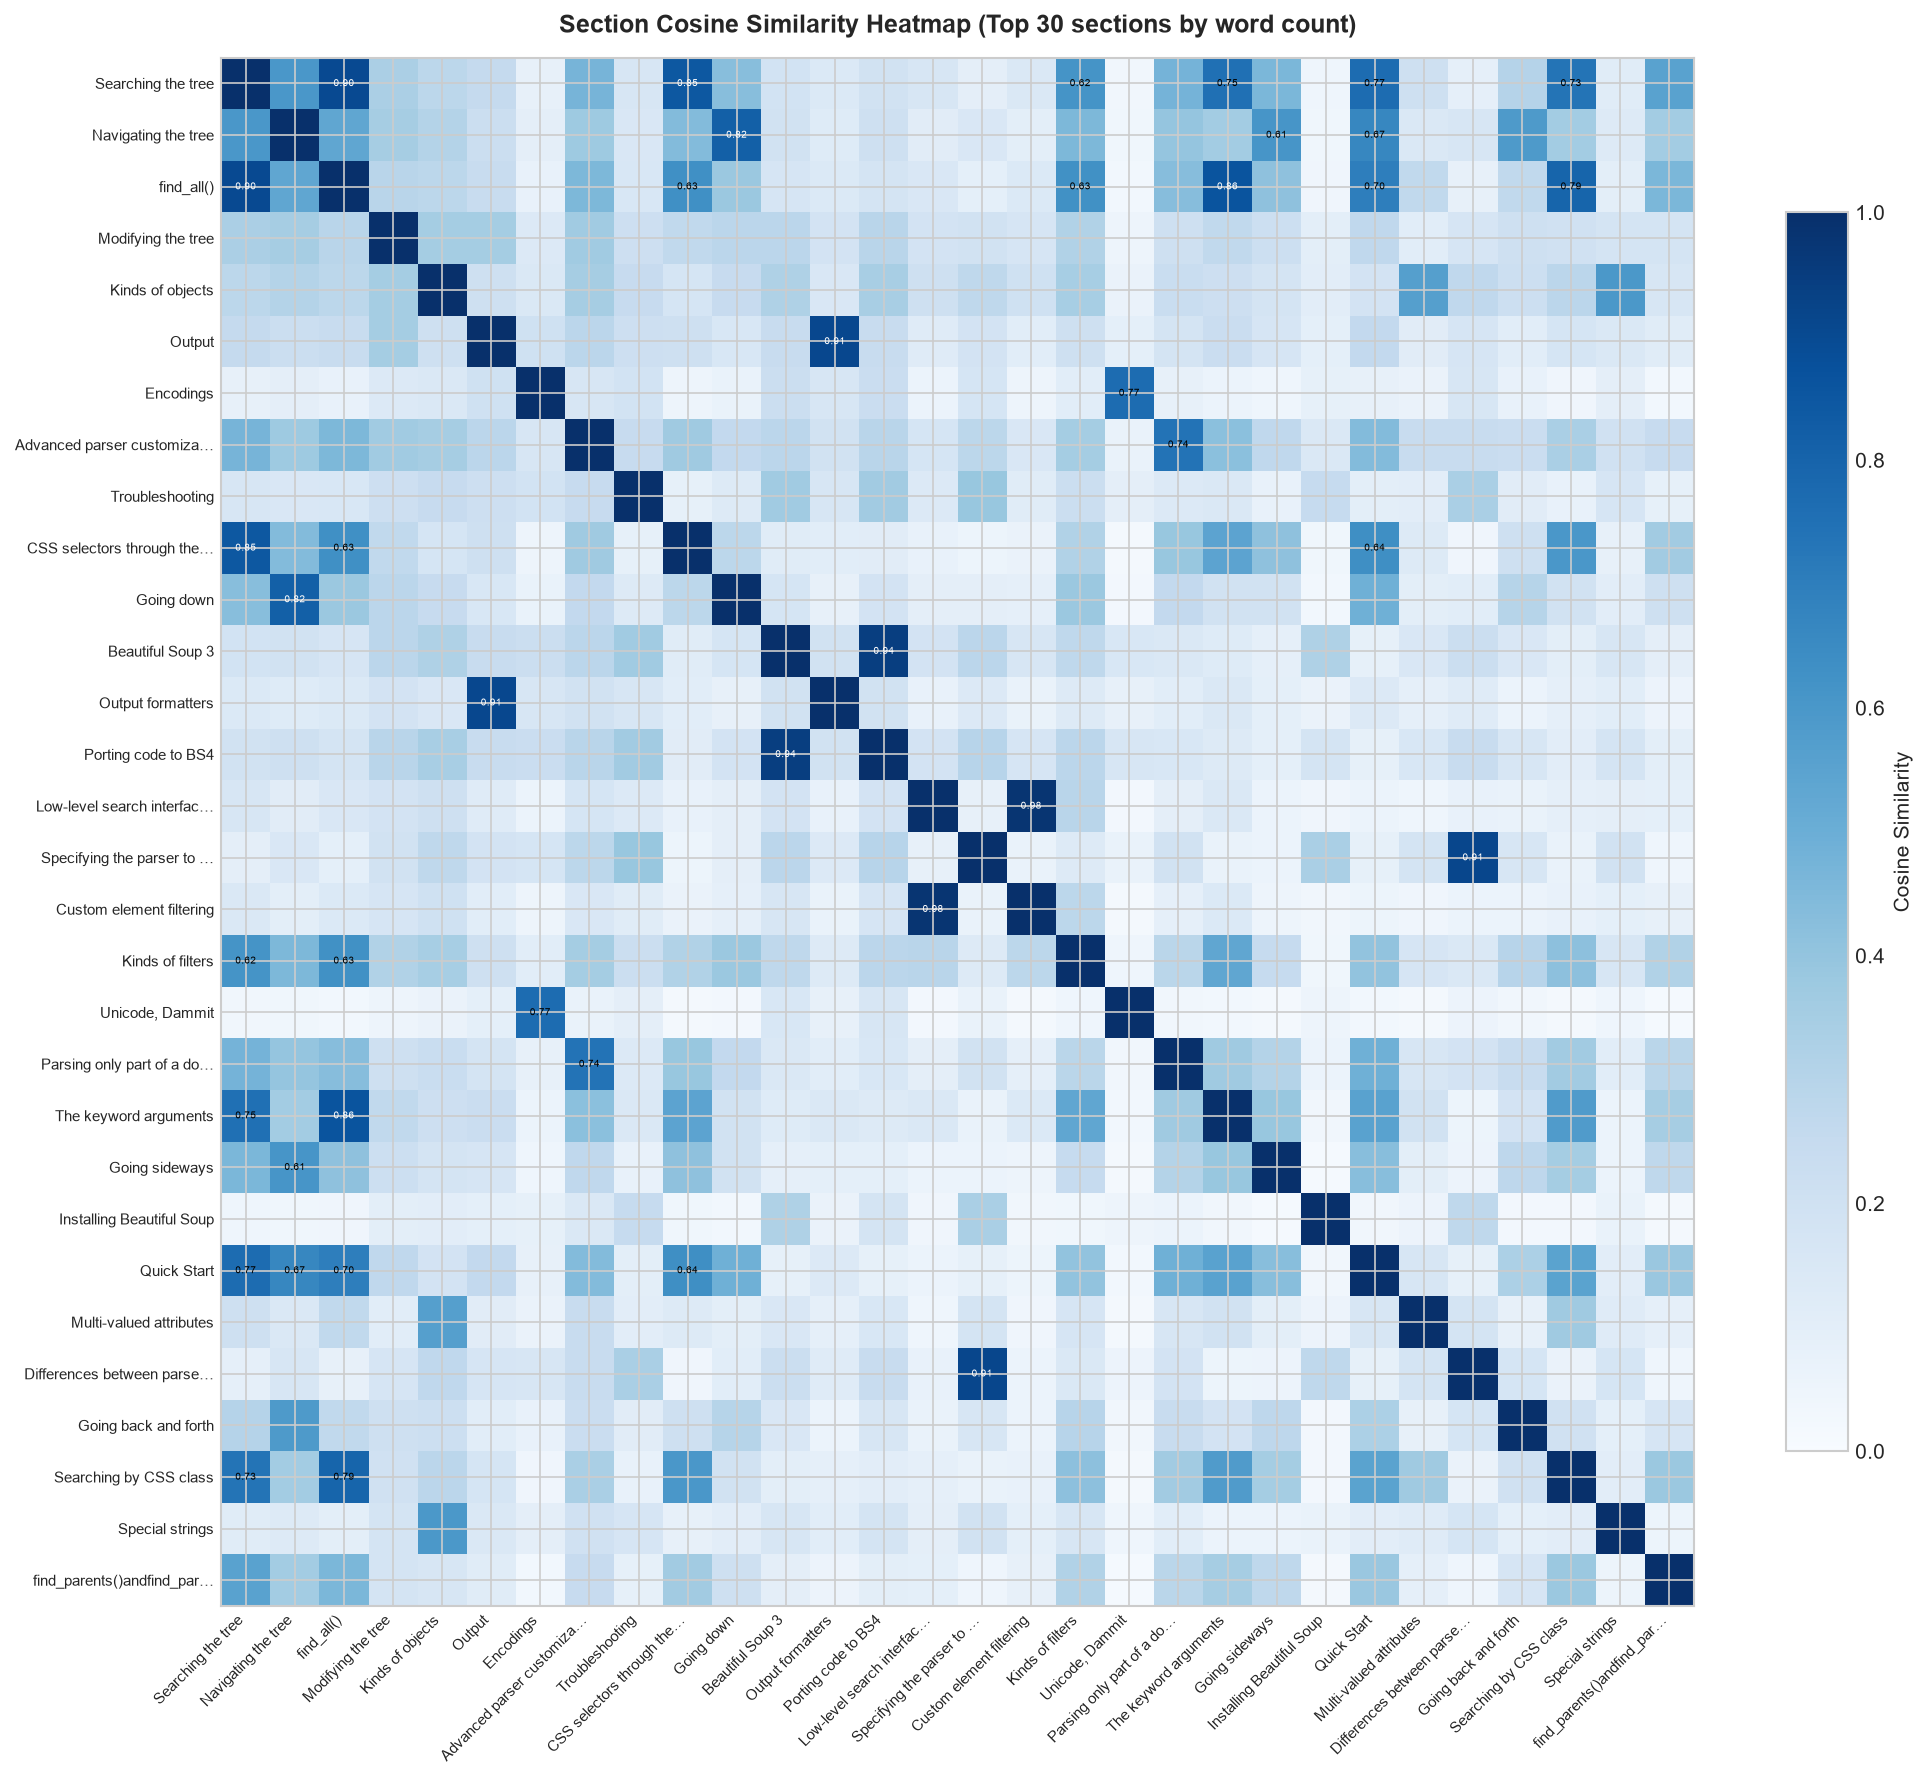

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

vec2   = TfidfVectorizer(stop_words='english')
X2     = vec2.fit_transform(sections['section_text'].fillna(''))
matrix = cosine_similarity(X2)
titles = sections['section_title'].tolist()

# Top similar pairs
pairs = []
n = len(titles)
for i in range(n):
    for j in range(i+1, n):
        pairs.append((titles[i], titles[j], float(matrix[i,j])))
pairs.sort(key=lambda x: -x[2])

print('Top 10 most similar section pairs:')
for a, b, score in pairs[:10]:
    print(f'  {score:.3f}  {a[:35]:<35} ↔  {b[:35]}')

# Show heatmap chart
Image(str(CHARTS_DIR / 'similarity_heatmap.png'))

## Key Findings

### F1 - Documentation depth is heavily asymmetric
**Searching the tree** contains **4,711 words** - more than double the second-longest section (Navigating the tree: 2,104 words) and **13x the median** section length. The bottom half of all sections each contain fewer than 200 words. This asymmetry accurately reflects the library's design: searching and navigating the parse tree are the operations users perform most, so the documentation invests proportionally.

### F2 - find_all() is the undisputed central API method
Of **220 code examples**, `find_all()` appears in **41 (18.6%)** - more than any other method. `get_text()` appears in only 4 (1.8%), and `select()` in between. The method usage chart (Advanced A - method_usage.png) shows the clear dominance of search-oriented methods over text-extraction methods, confirming that BeautifulSoup is primarily used as a search and navigation tool.

### F3 - The documentation is almost entirely self-referential
Of **376 links**, **342 (90.9%) are internal anchors** pointing to other sections of the same page. Only 21 are external links. This makes the documentation a nearly closed system - it extensively cross-references itself rather than pointing outward to related resources.

### F4 - TF-IDF surfaces 'tag' as the most conceptually central term
Raw frequency (Q5) ranks `soup` first (926 times), but TF-IDF analysis weights terms by how distinctive they are *across* sections - surfacing `tag` (13.30) ahead of `soup` (13.26). This distinction matters: `soup` appears as boilerplate in nearly every section, while `tag` is the conceptually central object that the API is built around. The side-by-side comparison chart (tfidf_keywords.png) visualises this gap clearly.

### F5 - Section similarity exposes tight conceptual clusters
Cosine similarity analysis (Advanced A3) reveals pairs scoring > 0.90:
- **Low-level search interface ↔ Custom element filtering** (0.977) - nearly identical vocabulary, two facets of the same advanced search concept
- **Beautiful Soup 3 ↔ Porting code to BS4** (0.938) - the migration guide reuses BS3 terminology throughout
- **Going sideways ↔ .next_sibling and .previous_sibling** (0.926) - conceptual description vs API description using the same terms

### F6 - Documentation sits at standard readability for a technical audience
Mean Flesch Reading Ease: **55.99** (Standard / Fairly Difficult band, 50–60). This is appropriate for developer documentation. The readability chart shows a roughly normal distribution with a long tail of low-scoring sections - those are the advanced parser internals and encoding sections, which are genuinely more complex to explain.

## Limitations

- **Single-page, single-version source.** Analysis covers only the current English BS4 documentation at time of scraping.
- **Network dependency** for initial collection. The `--skip-fetch` flag mitigates this for re-runs.
- **Section boundaries rely on heading structure.** Content before the first heading (table of contents, navigation) is attributed to 'Unknown' or to the TOC section. The TOC's 128 links are a structural artefact, not meaningful content links.
- **'sister' in top keywords is an example-data artefact.** The documentation uses a fictional HTML document featuring three sisters from Alice in Wonderland. 'sister' (286 occurrences) reflects example data, not a BS4 concept. TF-IDF partially mitigates this by downweighting terms uniform across sections.
- **Readability scores are computed on mixed content.** Code snippets, HTML fragments, and Python identifiers are included in section text, inflating syllable counts and distorting Flesch scores downward.
- **Code example attribution is approximate.** The nearest preceding heading in the DOM is used as the parent section. Sphinx sometimes nests code examples in ways that cause attribution to a subsection rather than the logical parent.

## Conclusion

This project demonstrates a complete end-to-end data engineering pipeline applied to real-world technical documentation. Starting from a single HTTP request, the system:

1. **Collected** and preserved raw HTML for reproducible analysis
2. **Parsed** the document into **113 sections** across three heading levels
3. **Extracted** **376 hyperlinks** (5 types) and **220 code examples** (5 method flags)
4. **Answered 10 analytical questions** with Pandas and NumPy
5. **Generated 8 charts** covering both required visualisations and advanced NLP-derived insights
6. **Applied TF-IDF, cosine similarity, and readability scoring** to surface deeper patterns
7. **Exposed all data** through a FastAPI REST API with an interactive Streamlit frontend

The most significant insight is the **asymmetric investment** in the documentation: 'Searching the tree' alone contains more content than the bottom 60 sections combined, and `find_all()` is demonstrated nearly 10× more than `get_text()`. This asymmetry is not a documentation flaw — it accurately reflects how BeautifulSoup is used in practice.

The cosine similarity analysis revealed that the documentation clusters tightly around a few conceptual families (search methods, tree navigation, output formatting), with high overlap between closely-related API concepts. This suggests the documentation was written with strong thematic coherence rather than isolated topic pages.

Future work could extend the pipeline to compare multiple documentation sources, enabling cross-library analysis of how different Python projects document their APIs.